# Feature Engineering in ML - Telugu English Mix Notes

## Architecture Diagram

```text
[Raw Data]
    |
    v
[Data Understanding]
    |
    v
[Missing Value Handling]
    |
    v
[Encoding + Scaling + Transformation]
    |
    v
[New Feature Creation]
    |
    v
[Feature Selection]
    |
    v
[ML Model Training]
    |
    v
[Evaluation + Iteration]
```

## Deep Architecture Notes

- **Step 1:** Raw data ante real-world nunchi vachina original data. Idi direct ga model ki ivvadam usually correct kaadu, because missing values, text columns, outliers, different scales untayi.
- **Step 2:** Data understanding lo columns meaning, data types, missing values, unique categories, distribution anni check chestham.
- **Step 3:** Missing values ni impute chestham. Numeric columns lo mean/median, categorical columns lo most frequent value common ga use chestham.
- **Step 4:** Categorical text values ni numeric format ki convert chestham, because ML models mostly numbers tho work chestayi.
- **Step 5:** Numeric values different ranges lo unte scaling chestham. Example salary 50000 range lo untundi, age 20-60 range lo untundi; scaling valla model balanced ga learn chestundi.
- **Step 6:** Existing columns nunchi new meaningful columns create chestham. Idi feature engineering lo main power.
- **Step 7:** Final features ni model ki pass chesi train chestham, evaluate chestham, improve chestham.


## Feature Engineering Ante Enti?

Feature engineering ante raw data ni ML model ki better ga artham ayye format lo convert cheyyadam. Model ki data ela chupistamo, learning quality mostly dani meeda depend avutundi.

Simple ga cheppali ante:

- Raw columns lo noise, missing values, text categories, scale differences untayi.
- Feature engineering valla aa raw columns useful signals ga marutayi.
- Good features unte simple model kuda strong performance ivvachu.
- Bad features unte complex model kuda confuse avvachu.

Example: `purchase_date` oka raw column. Danni direct ga model ki ivvakunda `purchase_month`, `purchase_day_of_week`, `is_weekend` laga split chesthe model ki pattern easy ga telustundi.


## Main Types of Feature Engineering

| Technique | Meaning | Example |
|---|---|---|
| Missing value handling | Empty values ni fill cheyyadam | age missing unte median age use cheyyadam |
| Encoding | Text categories ni numbers ga convert cheyyadam | city = Hyderabad, Chennai -> one-hot columns |
| Scaling | Numeric ranges ni comparable ga cheyyadam | salary and age same scale lo ki teesukuravadam |
| Transformation | Skewed values ni smooth cheyyadam | income meeda log transform |
| Feature creation | Existing data nunchi new columns create cheyyadam | income_per_year = income / experience |
| Binning | Continuous value ni groups ga divide cheyyadam | age -> young, adult, senior |
| Feature selection | Useful columns matrame keep cheyyadam | low-signal columns remove cheyyadam |


In [14]:
# pandas library ni table-style data handle cheyyadaniki import chestunnam.
import pandas as pd

# numpy library ni numeric operations kosam import chestunnam.
import numpy as np

# matplotlib plotting library ni basic charts kosam import chestunnam.
import matplotlib.pyplot as plt

# seaborn library ni clean visualizations kosam import chestunnam.
import seaborn as sns

# train_test_split ni data ni train and test parts ga divide cheyyadaniki import chestunnam.
from sklearn.model_selection import train_test_split

# ColumnTransformer ni different column groups ki different preprocessing apply cheyyadaniki import chestunnam.
from sklearn.compose import ColumnTransformer

# Pipeline ni preprocessing and model ni single workflow ga connect cheyyadaniki import chestunnam.
from sklearn.pipeline import Pipeline

# SimpleImputer ni missing values fill cheyyadaniki import chestunnam.
from sklearn.impute import SimpleImputer

# OneHotEncoder ni categorical text values ni numeric one-hot columns ga marchadaniki import chestunnam.
from sklearn.preprocessing import OneHotEncoder

# StandardScaler ni numeric columns ni same scale lo ki teesukuradaniki import chestunnam.
from sklearn.preprocessing import StandardScaler

# LogisticRegression ni simple classification model ga use cheyyadaniki import chestunnam.
from sklearn.linear_model import LogisticRegression

# accuracy_score ni model prediction quality measure cheyyadaniki import chestunnam.
from sklearn.metrics import accuracy_score

# classification_report ni precision, recall, f1-score detailed ga chudataniki import chestunnam.
from sklearn.metrics import classification_report

# charts default style ni neat ga set chestunnam.
sns.set_theme(style="whitegrid")


## Example Dataset Create Cheddam

Ippudu oka small employee dataset create chestham. Target column `will_leave` ante employee company leave chestada leda ani binary classification problem.

Raw columns:

- `age`: employee age
- `monthly_salary`: salary value
- `experience_years`: work experience
- `department`: categorical column
- `city`: categorical column
- `joining_date`: date column
- `projects_completed`: numeric performance signal
- `will_leave`: target label


In [15]:
# reproducible random values kosam seed set chestunnam.
np.random.seed(42)

# dataset size ni rows count laga define chestunnam.
row_count = 80

# sample employee data ni dictionary format lo create chestunnam.
employee_data = {
    # age values ni realistic employee range lo generate chestunnam.
    "age": np.random.randint(22, 58, row_count).astype(float),
    # salary values ni normal distribution nunchi generate chestunnam.
    "monthly_salary": np.random.normal(75000, 18000, row_count).round(0),
    # experience values ni employee range ki suitable ga generate chestunnam.
    "experience_years": np.random.randint(0, 25, row_count).astype(float),
    # department categorical values ni random ga select chestunnam.
    "department": np.random.choice(["Engineering", "Sales", "HR", "Finance"], row_count),
    # city categorical values ni random ga select chestunnam.
    "city": np.random.choice(["Hyderabad", "Bengaluru", "Chennai", "Pune"], row_count),
    # joining dates ni monthly frequency tho generate chestunnam.
    "joining_date": pd.date_range("2018-01-01", periods=row_count, freq="30D"),
    # projects completed values ni integer range lo generate chestunnam.
    "projects_completed": np.random.randint(1, 18, row_count),
}

# dictionary ni pandas DataFrame ga convert chestunnam.
employee_dataframe = pd.DataFrame(employee_data)

# salary low and experience low unte leave chance high ani synthetic target create chestunnam.
leave_score = (employee_dataframe["monthly_salary"] < 70000).astype(int) + (employee_dataframe["experience_years"] < 3).astype(int)

# leave score plus random noise base chesi target label create chestunnam.
employee_dataframe["will_leave"] = ((leave_score + np.random.binomial(1, 0.25, row_count)) >= 1).astype(int)

# age column lo konni values missing ga set chestunnam.
employee_dataframe.loc[[4, 16, 31], "age"] = np.nan

# salary column lo konni values missing ga set chestunnam.
employee_dataframe.loc[[9, 27], "monthly_salary"] = np.nan

# department column lo oka missing value set chestunnam.
employee_dataframe.loc[12, "department"] = np.nan

# first few rows display chestunnam.
employee_dataframe.head(10)


,age,monthly_salary,experience_years,department,city,joining_date,projects_completed,will_leave
0,50.0,91098.0,5.0,Finance,Chennai,2018-01-01,12,0
1,36.0,88590.0,15.0,Finance,Pune,2018-01-31,5,0
2,29.0,71271.0,2.0,Finance,Bengaluru,2018-03-02,7,1
3,42.0,63777.0,19.0,HR,Pune,2018-04-01,4,1
4,NaN,47853.0,3.0,HR,Bengaluru,2018-05-01,6,1
5,44.0,94794.0,18.0,Engineering,Pune,2018-05-31,13,0
6,32.0,71801.0,2.0,Finance,Chennai,2018-06-30,15,1
7,32.0,67613.0,18.0,Engineering,Bengaluru,2018-07-30,3,1
8,45.0,96235.0,19.0,Finance,Chennai,2018-08-29,8,0
9,57.0,NaN,6.0,Finance,Bengaluru,2018-09-28,16,1


## Data Understanding

Feature engineering start cheyyadaniki mundu data ni observe cheyyali. Missing values ekkada unnayi, numeric columns distribution ela undi, categorical values enti ani chudali.


In [16]:
# data shape ni rows and columns count laga print chestunnam.
print("Shape:", employee_dataframe.shape)

# prathi column lo missing values count ni print chestunnam.
print("\nMissing values:")
print(employee_dataframe.isna().sum())

# numeric columns basic statistics ni display chestunnam.
employee_dataframe.describe(include="all")


Shape: (80, 8)

Missing values:
age                   3
monthly_salary        2
experience_years      0
department            1
city                  0
joining_date          0
projects_completed    0
will_leave            0
dtype: int64


,age,monthly_salary,experience_years,department,city,joining_date,projects_completed,will_leave
count,77.000000,78.000000,80.00000,79,80,80,80.000000,80.000000
unique,NaN,NaN,NaN,4,4,NaN,NaN,NaN
top,NaN,NaN,NaN,Finance,Bengaluru,NaN,NaN,NaN
freq,NaN,NaN,NaN,23,26,NaN,NaN,NaN
mean,38.714286,75881.653846,11.60000,NaN,NaN,2021-03-31 00:00:00,8.550000,0.625000
min,22.000000,27207.000000,0.00000,NaN,NaN,2018-01-01 00:00:00,1.000000,0.000000
25%,30.000000,66391.750000,3.75000,NaN,NaN,2019-08-16 12:00:00,4.000000,0.000000
50%,39.000000,74766.500000,13.00000,NaN,NaN,2021-03-31 00:00:00,8.000000,1.000000
75%,46.000000,88755.750000,19.00000,NaN,NaN,2022-11-13 12:00:00,13.000000,1.000000
max,57.000000,135701.000000,24.00000,NaN,NaN,2024-06-28 00:00:00,17.000000,1.000000


## Source Notebook Section: Handling Missing Values

Ee section `1.0-+Handling+Missing+values+(1).ipynb` notebook content ni same order lo explain chestundi. Original notebook lo unna concept flow: Missing Values -> MCAR -> MAR -> MNAR -> Titanic dataset examples -> deletion -> imputation techniques.

### Original line: Missing Values
Explanation: Missing values ante dataset lo konni cells empty ga undadam. Column undi, row undi, kaani value store avvaledu ante adi missing value.

### Original line: Missing values occurs in dataset when some of the informations is not stored for a variable
Explanation: Dataset lo oka variable/column ki required information collect avvakapothe leda save avvakapothe `NaN` laga kanipistundi. Example: passenger age unknown, embarked city missing, income not reported.

### Original line: There are 3 mechanisms
Explanation: Missing values enduku vachayo broadly 3 mechanisms tho understand chestham: MCAR, MAR, MNAR.


### 1. Missing Completely at Random, MCAR

Original meaning: MCAR lo missing value probability observed data meeda kuda depend kaadu, missing data actual value meeda kuda depend kaadu.

Simple Telugu-English explanation: Missing values completely random ga spread avutayi. System glitch, random survey form loss, random sensor failure lanti cases lo missingness ki clear pattern undadu.

Example: Disease survey lo random participants answers save avvaledu. Aa missing answers disease status, age, gender, actual response value emi batti kaadu; random issue valla missing ayyayi.

ML impact: MCAR relatively less biased. Rows delete cheyyadam sometimes acceptable, but data size small unte imputation better.


### 2. Missing at Random, MAR

Original meaning: MAR lo missing value probability observed data meeda depend avutundi, but missing value itself meeda depend avvadu.

Simple Telugu-English explanation: Missingness random laga kanipinchina, actually observed column tho relation untundi. Example: younger people income report cheyyakapovachu. Ikkada income missing avvadam age/gender lanti observed variables meeda depend avutundi.

Income example: Participants income report cheyyadam age or gender meeda depend aithe, but actual income amount meeda depend kakapothe, adi MAR.

Medical example: Younger or healthier patients blood pressure report cheyyakapothe, missingness lifestyle/age observed columns meeda depend avutundi.

ML impact: MAR lo imputation cheyyadaniki related observed columns ni include cheyyali. Simple mean fill sometimes weak avvachu.


### 3. Missing Data Not at Random, MNAR

Original meaning: MNAR lo missing value probability missing value actual value meeda depend avutundi.

Simple Telugu-English explanation: Value sensitive, extreme, or uncomfortable kabatti missing avutundi. Missingness itself hidden information carry chestundi.

Example: Employees job satisfaction low ga unte income report cheyyadaniki refuse cheyyachu. Ikkada missingness job satisfaction/income actual hidden value tho related.

ML impact: MNAR most risky. Simple mean/median imputation bias create cheyyachu. Missing indicator features, domain investigation, better data collection, or special modeling kavali.


## Examples - Titanic Dataset Tho Missing Values Handle Cheddam

Original notebook ikkada seaborn Titanic dataset use chestundi. Titanic dataset lo `age`, `deck`, `embarked`, `embark_town` lanti columns lo missing values untayi, so missing value handling practice ki useful.


In [17]:
# seaborn library ni datasets load cheyyadaniki and visualization kosam import chestunnam.
import seaborn as sns


In [18]:
# seaborn built-in Titanic dataset ni load chesi df variable lo store chestunnam.
df = sns.load_dataset("titanic")


In [19]:
# dataframe first 5 rows display chestunnam, data columns and sample values understand cheyyadaniki.
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [20]:
# prathi column lo enni missing values unnayo count cheyyadaniki isnull use chestunnam.
# sum function True values ni count chestundi, because True = 1 and False = 0 laga treat avutayi.
df.isnull().sum()


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [21]:
# rows delete cheyyadaniki mundu dataframe original shape check chestunnam.
# shape output lo first value rows count, second value columns count.
df.shape


(891, 15)

In [22]:
# dropna default ga missing value unna rows ni remove chestundi.
# shape check chesthe rows entha taggayo telustundi.
df.dropna().shape


(182, 15)

In [23]:
# axis=1 ante row deletion kaadu, column deletion ani meaning.
# missing value unna columns ni remove chesi remaining dataframe display chestunnam.
df.dropna(axis=1)


,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


## Imputation Missing Values

Imputation ante missing values ni reasonable estimated value tho fill cheyyadam. Rows/columns delete cheyyakunda data retain cheyyadaniki idi useful.

### 1. Mean Value Imputation

Mean imputation lo missing numeric values ni aa column average value tho fill chestham. Data approximately normally distributed unte mean imputation okay. Outliers unte mean distort avvachu.


<Axes: xlabel='age', ylabel='Count'>

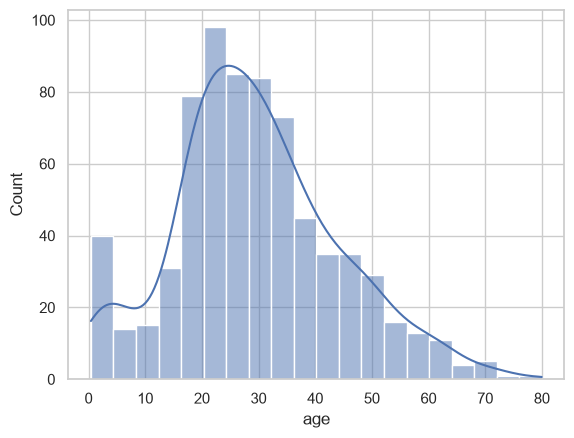

In [24]:
# age column distribution chudataniki histogram plot chestunnam.
# kde=True ante smooth density curve kuda chart lo show avutundi.
sns.histplot(df["age"], kde=True)


In [25]:
# age column mean value calculate chesi missing age values ni fill chestunnam.
# new column Age_mean create chestunnam, original age column safe ga undadaniki.
df["Age_mean"] = df["age"].fillna(df["age"].mean())


In [26]:
# original age and mean-imputed Age_mean columns ni side-by-side compare chestunnam.
# age NaN unna rows lo Age_mean column lo average age value kanipistundi.
df[["Age_mean", "age"]]


,Age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


### Mean Imputation Works Well When Data Is Normally Distributed

Original notebook lo comment ga unna point: Mean imputation normally distributed data ki better. Reason enti ante normal distribution lo mean center value ni represent chestundi. Kaani skewed data or outliers unte mean wrong central value laga behave cheyyachu.


### 2. Median Value Imputation - Outliers Unnapudu

Median imputation lo missing numeric values ni middle value tho fill chestham. Outliers unna datasets lo median mean kanna stable ga untundi.


In [27]:
# age column median value calculate chesi missing age values ni fill chestunnam.
# new column age_median create chestunnam, mean and median imputation compare cheyyadaniki.
df["age_median"] = df["age"].fillna(df["age"].median())


In [28]:
# median-imputed, mean-imputed, original age columns ni side-by-side display chestunnam.
# difference chusthe mean vs median imputation effect easy ga ardham avutundi.
df[["age_median", "Age_mean", "age"]]


,age_median,Age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


### 3. Mode Imputation Technique - Categorical Values

Mode imputation categorical columns kosam common technique. Mode ante most frequent value. Example `embarked` column lo most common port ni missing rows lo fill cheyyachu.


In [29]:
# embarked column missing unna rows ni filter chestunnam.
# idi missing categorical values actual rows lo ela kanipistayo chudataniki.
df[df["embarked"].isnull()]


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [30]:
# embarked column lo unique categories enti ani check chestunnam.
# output lo S, C, Q and NaN lanti values kanipistayi.
df["embarked"].unique()


<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [31]:
# embarked column lo non-missing values matrame select chestunnam.
# mode()[0] most frequent embarked category ni return chestundi.
mode_value = df[df["embarked"].notna()]["embarked"].mode()[0]


In [32]:
# embarked missing values ni mode_value tho fill chestunnam.
# new column embarked_mode create chestunnam, original embarked column preserve cheyyadaniki.
df["embarked_mode"] = df["embarked"].fillna(mode_value)


In [33]:
# original embarked and mode-imputed embarked_mode columns ni compare chestunnam.
# missing rows lo embarked_mode value fill ayyindo verify cheyyachu.
df[["embarked_mode", "embarked"]]


,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [34]:
# imputation taruvatha embarked_mode column lo missing values count check chestunnam.
# expected output 0, because missing values mode tho fill ayyayi.
df["embarked_mode"].isnull().sum()


np.int64(0)

In [35]:
# original embarked column lo missing values count check chestunnam.
# original column unchanged undi kabatti missing count still original value ga untundi.
df["embarked"].isnull().sum()


np.int64(2)

## Original Notebook Empty Cells Note

Original downloaded notebook lo last side lo konni empty code cells unnayi. Empty cells lo executable code ledu, kabatti target notebook lo separate empty cells add cheyyaledu. Content loss ledu, because explain cheyyadaniki actual code/source lines avi contain cheyyaledu.


## Source Notebook Section: Handling Imbalanced Dataset

Ee topic lo main confusion usually idi: **code lo rows duplicate/reduce chestunnam, kaani why?**

Imbalanced dataset ante target classes equal ga levu. Example fraud detection lo 1000 transactions lo 990 normal and 10 fraud undachu. Model ki normal examples chala ekkuva kanipistayi, fraud examples chala takkuva kanipistayi. Appudu model easy shortcut nerchukuntundi: "mostly normal ani predict chesthe accuracy high vastundi". Kaani mana actual goal minority class ni catch cheyyadam.

Original notebook points:

1. **Up Sampling** - minority class rows ni resample chesi majority class count ki equal cheyyadam.
2. **Down Sampling** - majority class rows ni reduce chesi minority class count ki equal cheyyadam.

### Overall Logic Flow

```text
[Create/Load Data]
        |
        v
[Check target value_counts]
        |
        v
[Is one class too high and one class too low?]
        |
        +--> Yes: Imbalanced Dataset
        |
        v
[Split majority and minority classes]
        |
        +--> [Upsampling: minority ni increase cheyyi]
        |
        +--> [Downsampling: majority ni reduce cheyyi]
        |
        v
[Balanced Dataset]
        |
        v
[Model train chesthe both classes equal attention pondutayi]
```

Important: Ikkada model train cheyyadam main focus kaadu. First step: **dataset balance ela chestham and why chestham** ani understand cheyyadam.


In [70]:
# WHAT: numpy library ni import chestunnam because random numeric values generate cheyyali.
# WHY: sample imbalanced dataset create cheyyadaniki random numbers kavali.
import numpy as np

# WHAT: pandas library ni import chestunnam because table/dataframe create cheyyali.
# WHY: ML datasets ni rows and columns format lo handle cheyyadam pandas tho easy.
import pandas as pd

# WHAT: random seed set chestunnam.
# WHY: notebook malli run chesina same random values ravali; appudu output consistent ga untundi.
np.random.seed(123)

# WHAT: total dataset lo 1000 rows/samples undali ani decide chestunnam.
# WHY: imbalance demo clear ga kanipinchadaniki enough rows kavali.
n_samples = 1000

# WHAT: class 0 ki 90 percent rows allocate chestunnam.
# WHY: class 0 majority class ani artificially create cheyyali; imbalance meaning practical ga kanipistundi.
class_0_ratio = 0.9

# WHAT: 1000 lo 90 percent ante 900 rows class 0 ki calculate chestunnam.
# WHY: majority class count exact ga know cheyyali, later balancing compare cheyyadaniki.
n_class_0 = int(n_samples * class_0_ratio)

# WHAT: remaining rows ni class 1 count ga calculate chestunnam.
# WHY: class 1 minority class avvali; 1000 - 900 = 100 rows.
n_class_1 = n_samples - n_class_0


### Why are we checking `n_class_0, n_class_1`?

Ikkada `900, 100` output vastundi. Meaning: class 0 daggara 900 examples unnayi, class 1 daggara 100 examples matrame unnayi. Model training lo class 0 examples 9 times ekkuva kanipistayi. So model class 0 side ki biased avvadam natural.


In [71]:
# WHAT: majority and minority class counts ni display chestunnam.
# WHY: imbalance ratio actual ga 900:100 ani verify cheyyali. Verify cheyyakunda resampling start cheyyakudadhu.
n_class_0, n_class_1


(900, 100)

## Create DataFrame With Imbalanced Dataset

Ikkada synthetic dataset create chestham. Synthetic ante real data kaadu, learning/demo kosam artificial ga create chesina data.

**What are we doing?**

- `class_0` dataframe lo 900 rows create chestham.
- `class_1` dataframe lo 100 rows create chestham.
- Rendu classes ki `feature_1`, `feature_2`, `target` columns untayi.

**Why are we doing this?**

Real-world imbalanced data dorakakapoyina, concept practice cheyyadaniki controlled example kavali. Class 0 data center `0` around untundi, class 1 data center `2` around untundi. Ivi model ki separable classes laga behave chestayi.


In [72]:
# WHAT: class 0 kosam majority dataframe create chestunnam.
# WHY: majority class examples chala ekkuva unna situation simulate cheyyali.
class_0 = pd.DataFrame({
    # WHAT: class 0 feature_1 values normal distribution nunchi create chestunnam.
    # WHY: loc=0 ante values mostly 0 around untayi; idi class 0 pattern.
    "feature_1": np.random.normal(loc=0, scale=1, size=n_class_0),
    # WHAT: class 0 feature_2 values kuda 0 around create chestunnam.
    # WHY: rendu features undadam valla later scatter plot/model demo easy avutundi.
    "feature_2": np.random.normal(loc=0, scale=1, size=n_class_0),
    # WHAT: target value 0 ni 900 times repeat chestunnam.
    # WHY: ee rows anni majority class ani label cheyyali.
    "target": [0] * n_class_0,
})

# WHAT: class 1 kosam minority dataframe create chestunnam.
# WHY: minority class examples takkuva unna situation simulate cheyyali.
class_1 = pd.DataFrame({
    # WHAT: class 1 feature_1 values normal distribution nunchi create chestunnam.
    # WHY: loc=2 ante values mostly 2 around untayi; class 0 kanna different pattern create avutundi.
    "feature_1": np.random.normal(loc=2, scale=1, size=n_class_1),
    # WHAT: class 1 feature_2 values kuda 2 around create chestunnam.
    # WHY: class 1 points scatter plot lo class 0 nunchi separate ga kanipinchadaniki.
    "feature_2": np.random.normal(loc=2, scale=1, size=n_class_1),
    # WHAT: target value 1 ni 100 times repeat chestunnam.
    # WHY: ee rows anni minority class ani label cheyyali.
    "target": [1] * n_class_1,
})


In [73]:
# WHAT: class_0 and class_1 dataframes ni one dataset ga combine chestunnam.
# WHY: ML model ki classes separate files/dataframes ga kaadu, single dataset lo target column tho kavali.
# reset_index(drop=True) old indexes remove chesi clean continuous index create chestundi.
imbalanced_df = pd.concat([class_0, class_1]).reset_index(drop=True)


In [74]:
# WHAT: dataset last 5 rows display chestunnam.
# WHY: manam concat lo class_1 ni end lo add chesam, so tail lo minority class target=1 rows kanipistayi.
imbalanced_df.tail()


,feature_1,feature_2,target
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1
999,2.697490,2.013570,1


In [75]:
# WHAT: target column lo class 0 and class 1 counts calculate chestunnam.
# WHY: dataset imbalance actual ga unda ani confirm cheyyali. Output 0=900, 1=100 ante imbalance clear.
imbalanced_df["target"].value_counts()


target
0    900
1    100
Name: count, dtype: int64

## Upsampling

**What are we doing?**

Minority class (`target=1`) lo 100 rows matrame unnayi. Danni 900 rows ki increase chestham, so class 0 and class 1 counts equal avutayi.

**Why are we doing it?**

Model training lo minority class examples repeated ga kanipisthe, model class 1 pattern ni ignore cheyyadu. Fraud/disease/churn lanti cases lo minority class important kabatti model ki aa class meeda enough learning signal ivvali.

**How are we doing it?**

`resample(..., replace=True, n_samples=len(df_majority))` use chestham. `replace=True` ante same minority row multiple times select avvachu. Idi duplicate-based balancing.


In [76]:
# WHAT: target 1 rows ni filter chesi minority dataframe create chestunnam.
# WHY: upsampling only minority class meeda apply cheyyali; majority class already enough rows kaligi undi.
df_minority = imbalanced_df[imbalanced_df["target"] == 1]

# WHAT: target 0 rows ni filter chesi majority dataframe create chestunnam.
# WHY: majority class count len(df_majority) ni target size ga use chestham, minority ni same count ki increase cheyyadaniki.
df_majority = imbalanced_df[imbalanced_df["target"] == 0]


In [77]:
# WHAT: sklearn resample utility ni import chestunnam.
# WHY: dataframe rows ni random ga sample cheyyadaniki built-in reliable helper.
from sklearn.utils import resample

# WHAT: minority class rows ni upsample chestunnam.
# WHY: minority count 100 nunchi majority count 900 ki increase cheyyali.
df_minority_upsampled = resample(
    # WHAT: sample cheyyalsina data minority dataframe.
    # WHY: increase cheyyalsindi minority class matrame.
    df_minority,
    # WHAT: replacement allow chestunnam.
    # WHY: 100 minority rows nunchi 900 rows create cheyyali ante same row multiple times pick avvali.
    replace=True,
    # WHAT: final sample size ni majority class count ki equal ga set chestunnam.
    # WHY: balanced dataset lo class 0 and class 1 counts same undali.
    n_samples=len(df_majority),
    # WHAT: random_state fixed chestunnam.
    # WHY: same notebook run chesina same sampled rows ravali.
    random_state=42,
)


In [78]:
# WHAT: upsample ayina minority dataframe shape check chestunnam.
# WHY: rows count 900 ayyinda ani verify cheyyali; lekapothe balancing correct ga jaragaledu.
df_minority_upsampled.shape


(900, 3)

In [79]:
# WHAT: upsampled minority dataframe first rows chustunnam.
# WHY: replacement sampling valla minority rows duplicate/ repeated patterns ga kanipinchachu ani understand cheyyadaniki.
df_minority_upsampled.head()


,feature_1,feature_2,target
951,1.125854,1.843917,1
992,2.196570,1.397425,1
914,1.932170,2.998053,1
971,2.272825,3.034197,1
960,2.870056,1.550485,1


In [80]:
# WHAT: original majority rows and upsampled minority rows ni combine chestunnam.
# WHY: final training dataset lo both classes kalisi undali; separate ga unte model train cheyyalem.
df_upsampled = pd.concat([df_majority, df_minority_upsampled])


In [81]:
# WHAT: upsampling taruvatha target counts malli check chestunnam.
# WHY: final result class 0=900 and class 1=900 ani prove cheyyali.
df_upsampled["target"].value_counts()


target
0    900
1    900
Name: count, dtype: int64

## Down Sampling

**What are we doing?**

Majority class (`target=0`) lo 900 rows unnayi. Danni 100 rows ki reduce chestham, so minority class (`target=1`) count ki equal avutundi.

**Why are we doing it?**

Model training lo majority class overwhelming ga kanipinchakunda reduce chestham. Dataset small and balanced avutundi, training fast avutundi.

**Risk enti?**

Majority class nunchi 800 rows discard chestham. Avi useful patterns contain chesi undachu. So downsampling simple but information loss risk undi.

**Original notebook note:**

Original downsampling section last resample line minority dataframe ni replacement tho sample chestundi, which is actually upsampling behavior. Correct downsampling: majority class ni `replace=False` tho minority count ki sample cheyyali.


In [82]:
# WHAT: random seed reset chestunnam.
# WHY: downsampling section independent ga run chesina same synthetic data ravali.
np.random.seed(123)

# WHAT: total rows count malli define chestunnam.
# WHY: original notebook downsampling section data ni fresh ga recreate chestundi, so same flow preserve chestunnam.
n_samples = 1000

# WHAT: majority class ratio 90 percent ga set chestunnam.
# WHY: malli imbalanced data create cheyyali before downsampling demo.
class_0_ratio = 0.9

# WHAT: class 0 rows count calculate chestunnam.
# WHY: majority class 900 rows undali.
n_class_0 = int(n_samples * class_0_ratio)

# WHAT: class 1 rows count calculate chestunnam.
# WHY: minority class 100 rows undali.
n_class_1 = n_samples - n_class_0

# WHAT: majority class dataframe recreate chestunnam.
# WHY: downsampling demo fresh dataset meeda clear ga explain cheyyadaniki.
class_0 = pd.DataFrame({
    # WHAT: class 0 feature_1 values 0 around generate chestunnam.
    # WHY: class 0 ki separate data pattern create cheyyali.
    "feature_1": np.random.normal(loc=0, scale=1, size=n_class_0),
    # WHAT: class 0 feature_2 values 0 around generate chestunnam.
    # WHY: two-feature dataset maintain cheyyali.
    "feature_2": np.random.normal(loc=0, scale=1, size=n_class_0),
    # WHAT: class 0 labels assign chestunnam.
    # WHY: model/resampling ki target class identify avvali.
    "target": [0] * n_class_0,
})

# WHAT: minority class dataframe recreate chestunnam.
# WHY: class 1 examples only 100 ga undali, imbalance maintain avvadaniki.
class_1 = pd.DataFrame({
    # WHAT: class 1 feature_1 values 2 around generate chestunnam.
    # WHY: minority class ki class 0 kanna different pattern create cheyyali.
    "feature_1": np.random.normal(loc=2, scale=1, size=n_class_1),
    # WHAT: class 1 feature_2 values 2 around generate chestunnam.
    # WHY: class separation visible ga undali.
    "feature_2": np.random.normal(loc=2, scale=1, size=n_class_1),
    # WHAT: class 1 labels assign chestunnam.
    # WHY: ee rows minority class ani mark cheyyali.
    "target": [1] * n_class_1,
})

# WHAT: majority and minority dataframes ni combine chestunnam.
# WHY: downsampling apply cheyyadaniki complete imbalanced dataset kavali.
imbalanced_df_for_downsampling = pd.concat([class_0, class_1]).reset_index(drop=True)

# WHAT: original class distribution print chestunnam.
# WHY: downsampling mundu imbalance 900:100 ani confirm cheyyali.
print(imbalanced_df_for_downsampling["target"].value_counts())


target
0    900
1    100
Name: count, dtype: int64


In [83]:
# WHAT: target 1 rows ni minority dataframe ga separate chestunnam.
# WHY: downsampling lo minority class unchanged ga keep chestham.
df_minority_down = imbalanced_df_for_downsampling[imbalanced_df_for_downsampling["target"] == 1]

# WHAT: target 0 rows ni majority dataframe ga separate chestunnam.
# WHY: reduce cheyyalsindi majority class matrame.
df_majority_down = imbalanced_df_for_downsampling[imbalanced_df_for_downsampling["target"] == 0]


In [84]:
# WHAT: majority class rows ni random ga subset select chestunnam.
# WHY: majority count 900 nunchi minority count 100 ki reduce cheyyali.
df_majority_downsampled = resample(
    # WHAT: sample cheyyalsina data majority dataframe.
    # WHY: downsampling lo majority class ni reduce chestham.
    df_majority_down,
    # WHAT: replacement disable chestunnam.
    # WHY: downsampling lo duplicate rows vaddu; original majority rows nunchi unique subset kavali.
    replace=False,
    # WHAT: sample size ni minority count ki equal chestunnam.
    # WHY: balanced dataset lo class 0 and class 1 both 100 rows undali.
    n_samples=len(df_minority_down),
    # WHAT: random state fixed chestunnam.
    # WHY: same downsampled rows repeatable ga ravali.
    random_state=42,
)


In [85]:
# WHAT: reduced majority and original minority dataframes ni combine chestunnam.
# WHY: final downsampled dataset lo both classes equal count tho undali.
df_downsampled = pd.concat([df_majority_downsampled, df_minority_down])

# WHAT: final class counts check chestunnam.
# WHY: downsampling successful aithe output class 0=100 and class 1=100 ravali.
df_downsampled["target"].value_counts()


target
0    100
1    100
Name: count, dtype: int64

In [86]:
# WHAT: downsampled dataframe first rows display chestunnam.
# WHY: final balanced dataset actual rows ela unnayo quick ga inspect cheyyadaniki.
df_downsampled.head()


,feature_1,feature_2,target
70,0.468439,1.720920,0
827,1.089165,-0.464899,0
231,0.753869,-0.969798,0
588,0.588686,-0.704720,0
39,0.283627,1.012868,0


## Imbalanced Dataset Key Points

- Imbalanced dataset lo model majority class ni easy shortcut laga learn chesukovachu.
- `value_counts()` first step, because class distribution numbers chudakunda imbalance decide cheyyalem.
- Upsampling lo minority class count increase chestham. Why: minority signal model ki ekkuva sari kanipinchali.
- Upsampling downside: duplicate rows valla overfitting risk undachu.
- Downsampling lo majority class count reduce chestham. Why: majority class dominance tagginchali.
- Downsampling downside: useful majority information discard avvachu.
- Real ML lo resampling train data meeda matrame cheyyali; test data original distribution lo undali.
- Accuracy alone imbalanced data lo misleading. Recall, precision, F1-score, PR-AUC kuda check cheyyali.

### One-line intuition

Imbalanced handling ante model ki rendu classes kuda important ani force cheyyadam Ã¢â‚¬â€ majority class loud ga matladutunte, minority class voice ni amplify cheyyadam or majority volume ni reduce cheyyadam.


## Source Notebook Section: SMOTE - Synthetic Minority Oversampling Technique

Ee section `3.0-SMOTE.ipynb` notebook content ni same order lo explain chestundi. SMOTE imbalanced dataset problem solve cheyyadaniki use chestham, especially minority class examples chala takkuva unna cases lo.

SMOTE full form: **Synthetic Minority Oversampling Technique**.

Simple ga: normal upsampling lo minority rows duplicate chestham. SMOTE lo duplicate cheyyakunda, existing minority points madhya synthetic/new points create chestham.

```text
[Imbalanced Data]
        |
        v
[Minority Class Points Identify]
        |
        v
[Nearest Minority Neighbors Find]
        |
        v
[Between Points Synthetic Samples Create]
        |
        v
[Balanced Dataset]
```

Important: SMOTE train data meeda matrame apply cheyyali. Train-test split mundu full data meeda SMOTE apply chesthe data leakage risk untundi.


In [53]:
# make_classification ni synthetic classification dataset create cheyyadaniki import chestunnam.
from sklearn.datasets import make_classification


In [54]:
# make_classification function tho imbalanced binary classification dataset create chestunnam.
smote_X, smote_y = make_classification(
    # total samples count 1000 ga set chestunnam.
    n_samples=1000,
    # redundant features zero ga set chestunnam, so rendu features useful/simple ga untayi.
    n_redundant=0,
    # total input features rendu matrame create chestunnam, plot lo easy ga visualize cheyyadaniki.
    n_features=2,
    # prathi class ki one cluster create chestunnam, visualization simple ga undadaniki.
    n_clusters_per_class=1,
    # class 0 ki 90 percent weight set chestunnam, class 1 automatically minority ga untundi.
    weights=[0.90],
    # reproducible dataset kosam random_state set chestunnam.
    random_state=12,
)


In [55]:
# pandas ni DataFrame create cheyyadaniki import chestunnam.
import pandas as pd

# features array ni dataframe ga convert chestunnam, columns names f1 and f2 ga set chestunnam.
smote_features_df = pd.DataFrame(smote_X, columns=["f1", "f2"])

# target array ni separate dataframe ga convert chestunnam.
smote_target_df = pd.DataFrame(smote_y, columns=["target"])

# features and target ni column-wise combine chesi final dataframe create chestunnam.
smote_final_df = pd.concat([smote_features_df, smote_target_df], axis=1)

# first five rows display chestunnam, generated data ela undi ani chudataniki.
smote_final_df.head()


,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [56]:
# target column class counts check chestunnam, imbalance confirm cheyyadaniki.
smote_final_df["target"].value_counts()


target
0    900
1    100
Name: count, dtype: int64

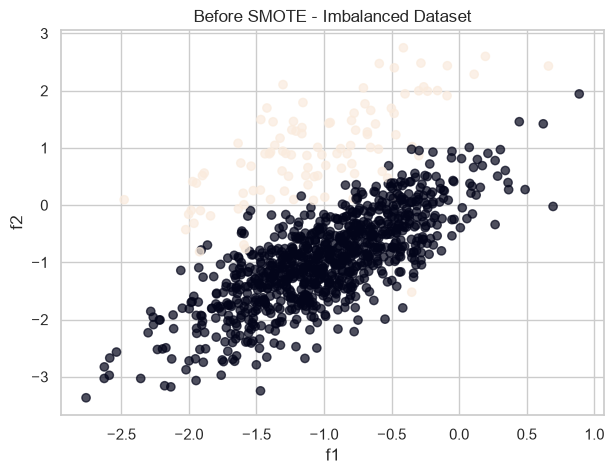

In [57]:
# matplotlib ni scatter plot draw cheyyadaniki import chestunnam.
import matplotlib.pyplot as plt

# figure size set chestunnam, chart readable ga undadaniki.
plt.figure(figsize=(7, 5))

# f1 and f2 features ni plot chestunnam, target class ni color laga use chestunnam.
plt.scatter(smote_final_df["f1"], smote_final_df["f2"], c=smote_final_df["target"], alpha=0.7)

# chart title set chestunnam.
plt.title("Before SMOTE - Imbalanced Dataset")

# x-axis label set chestunnam.
plt.xlabel("f1")

# y-axis label set chestunnam.
plt.ylabel("f2")

# chart display chestunnam.
plt.show()


### Package Note

Original notebook lo `!pip install imblearn` cell undi. Ee notebook kernel lo package ni clean ga install chesam using notebook package manager, so runtime lo install command repeat cheyyalsina avasaram ledu.

Correct package name usually `imbalanced-learn`, import name `imblearn`.


In [58]:
# SMOTE class ni imblearn library nunchi import chestunnam.
from imblearn.over_sampling import SMOTE


In [59]:
# SMOTE object create chestunnam, default settings tho synthetic minority samples generate cheyyadaniki.
oversample = SMOTE(random_state=42)

# original feature columns and target column ni SMOTE ki pass chestunnam.
# fit_resample minority class ki synthetic rows create chesi balanced X and y return chestundi.
smote_X_resampled, smote_y_resampled = oversample.fit_resample(smote_final_df[["f1", "f2"]], smote_final_df["target"])


In [60]:
# SMOTE taruvatha feature matrix shape check chestunnam.
# rows count increase avvali because minority class synthetic samples add avutayi.
smote_X_resampled.shape


(1800, 2)

In [61]:
# SMOTE taruvatha target array shape check chestunnam.
smote_y_resampled.shape


(1800,)

In [62]:
# resampled target lo class 0 count check chestunnam.
len(smote_y_resampled[smote_y_resampled == 0])


900

In [63]:
# resampled target lo class 1 count check chestunnam.
# expected ga class 0 count ki equal ga undali.
len(smote_y_resampled[smote_y_resampled == 1])


900

In [64]:
# resampled features ni dataframe ga convert chestunnam.
smote_oversampled_features_df = pd.DataFrame(smote_X_resampled, columns=["f1", "f2"])

# resampled target ni dataframe ga convert chestunnam.
smote_oversampled_target_df = pd.DataFrame(smote_y_resampled, columns=["target"])

# resampled features and target ni combine chesi oversampled dataframe create chestunnam.
smote_oversample_df = pd.concat([smote_oversampled_features_df, smote_oversampled_target_df], axis=1)

# SMOTE taruvatha class counts display chestunnam.
smote_oversample_df["target"].value_counts()


target
0    900
1    900
Name: count, dtype: int64

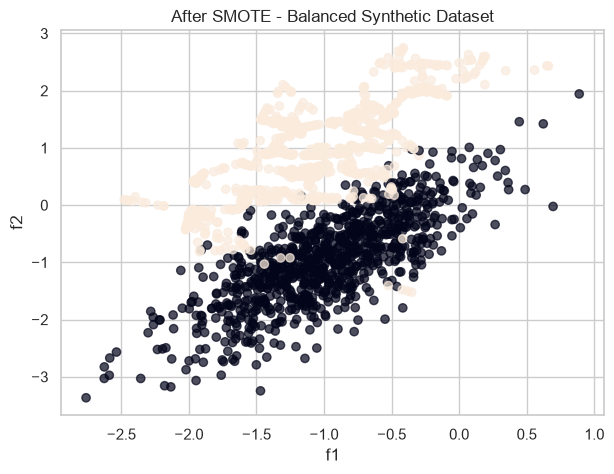

In [65]:
# SMOTE taruvatha data distribution visualize cheyyadaniki figure create chestunnam.
plt.figure(figsize=(7, 5))

# resampled f1 and f2 points plot chestunnam, target colors tho class separation chustunnam.
plt.scatter(smote_oversample_df["f1"], smote_oversample_df["f2"], c=smote_oversample_df["target"], alpha=0.7)

# chart title set chestunnam.
plt.title("After SMOTE - Balanced Synthetic Dataset")

# x-axis label set chestunnam.
plt.xlabel("f1")

# y-axis label set chestunnam.
plt.ylabel("f2")

# chart display chestunnam.
plt.show()


## SMOTE Key Points

- SMOTE duplicate rows create cheyyadu; minority class existing points madhya synthetic samples create chestundi.
- Random upsampling kanna overfitting risk konchem taggutundi, because exact duplicates kakunda new samples create avutayi.
- SMOTE numerical feature space lo neighbors use chestundi, so scaling sometimes important.
- Train-test split taruvatha train set meeda matrame SMOTE apply cheyyali.
- Noisy minority examples unte SMOTE noise ni kuda expand cheyyachu, so data quality check important.


## Source Notebook Section: Handling Outliers

Ee section `4.0-Handling+Outliers.ipynb` notebook content ni same order lo explain chestundi. Main topic: **5 number summary**, **IQR**, **lower fence**, **higher fence**, and **box plot** use chesi outliers identify cheyyadam.

### Outlier ante enti?

Outlier ante dataset lo majority values nunchi chala dooram unna unusual value. Example marks list lo most values 30 to 100 madhya unte, `-200` or `180` lanti values outliers laga behave chestayi.

### Why outliers handle cheyyali?

- Mean, standard deviation lanti statistics distort avvachu.
- Linear regression, logistic regression, KNN, SVM lanti models outliers valla impact avvachu.
- Data entry mistakes detect cheyyadaniki outlier analysis useful.
- Business/domain wise extreme values valid aa invalid aa decide cheyyadaniki outlier detection first step.

### Architecture Flow

```text
[Numeric Data]
      |
      v
[Calculate 5 Number Summary]
      |
      v
[Calculate IQR = Q3 - Q1]
      |
      v
[Lower Fence and Higher Fence]
      |
      v
[Values outside fences = possible outliers]
      |
      v
[Visualize with Box Plot]
```


## 5 Number Summary And Box Plot

Original notebook heading: **5 number Summary And Box Plot**.

5 number summary ante numeric data distribution ni simple ga describe chese 5 important values:

| Value | Meaning | Why useful? |
|---|---|---|
| Minimum | Smallest value | Data start point telustundi |
| Q1 | 25 percent data below this value | Lower side spread telustundi |
| Median | Middle value | Center value robust ga telustundi |
| Q3 | 75 percent data below this value | Upper side spread telustundi |
| Maximum | Largest value | Data end point telustundi |

Box plot ee 5-number summary ni visual ga chupistundi. Box middle lo Q1 to Q3 range untundi, line median, whiskers lower/higher fence range, and outside points outliers laga show avutayi.


In [87]:
# WHAT: Ee comment original notebook lo formula reminder laga undi.
# WHY: Outlier detection start cheyyadaniki Minimum, Maximum, Median, Q1, Q3, IQR values kavali.
# Minimum, Maximum, Median, Q1, Q3, IQR


In [88]:
# WHAT: numpy library ni numeric calculations kosam import chestunnam.
# WHY: np.quantile use chesi minimum, Q1, median, Q3, maximum calculate cheyyali.
import numpy as np


In [89]:
# WHAT: student marks sample list create chestunnam.
# WHY: outlier detection concept ni small numeric list meeda easy ga practice cheyyali.
outlier_marks = [45, 32, 56, 75, 89, 54, 32, 89, 90, 87, 67, 54, 45, 98, 99, 67, 74]

# WHAT: quantiles calculate chestunnam: 0%, 25%, 50%, 75%, 100%.
# WHY: ivi 5 number summary values. IQR and fences calculate cheyyadaniki Q1 and Q3 kavali.
minimum, Q1, median, Q3, maximum = np.quantile(outlier_marks, [0, 0.25, 0.50, 0.75, 1.0])


In [90]:
# WHAT: calculated 5-number summary values display chestunnam.
# WHY: data range and center visually understand cheyyadaniki first output chudali.
minimum, Q1, median, Q3, maximum


(np.float64(32.0),
 np.float64(54.0),
 np.float64(67.0),
 np.float64(89.0),
 np.float64(99.0))

In [91]:
# WHAT: IQR calculate chestunnam by subtracting Q1 from Q3.
# WHY: IQR middle 50 percent data spread ni measure chestundi; outlier fences formula ki idi base.
IQR = Q3 - Q1

# WHAT: IQR value print chestunnam.
# WHY: data spread entha undi ani direct ga chudali.
print(IQR)


35.0


In [92]:
# WHAT: lower fence calculate chestunnam.
# WHY: ee value kanna takkuva unna points possible low-side outliers.
lower_fence = Q1 - 1.5 * IQR

# WHAT: higher fence calculate chestunnam.
# WHY: ee value kanna ekkuva unna points possible high-side outliers.
higher_fence = Q3 + 1.5 * IQR


In [93]:
# WHAT: lower fence value display chestunnam.
# WHY: low-side outlier threshold enti ani know cheyyali.
lower_fence


np.float64(1.5)

In [94]:
# WHAT: higher fence value display chestunnam.
# WHY: high-side outlier threshold enti ani know cheyyali.
higher_fence


np.float64(141.5)

In [95]:
# WHAT: outlier fences outside unna marks identify chestunnam.
# WHY: formula result practically values meeda apply chesi outliers unnaya leda verify cheyyali.
outliers_without_extreme_values = [mark for mark in outlier_marks if mark < lower_fence or mark > higher_fence]

# WHAT: detected outliers display chestunnam.
# WHY: original marks list lo mostly normal values kabatti empty list ravachu.
outliers_without_extreme_values


[]

In [96]:
# WHAT: original clean marks list ni malli assign chestunnam.
# WHY: next boxplot clean data distribution ni show cheyyadaniki.
outlier_marks = [45, 32, 56, 75, 89, 54, 32, 89, 90, 87, 67, 54, 45, 98, 99, 67, 74]


In [97]:
# WHAT: seaborn library ni import chestunnam.
# WHY: boxplot create cheyyadam seaborn tho simple and clean ga untundi.
import seaborn as sns


<Axes: >

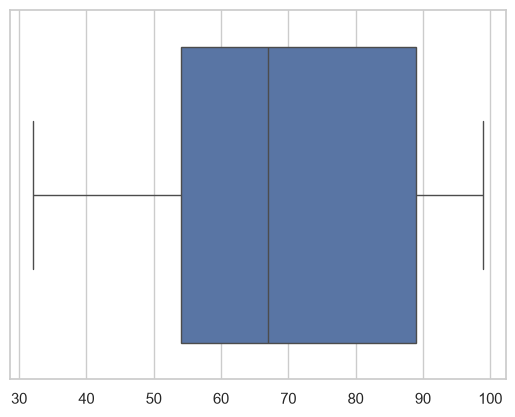

In [98]:
# WHAT: clean marks list ki boxplot draw chestunnam.
# WHY: normal data distribution lo box, median, whiskers ela kanipistayo observe cheyyali.
sns.boxplot(x=outlier_marks)


## Box Plot With Extreme Outliers

Original notebook next step lo same marks list ki `-100`, `-200`, `150`, `170`, `180` lanti extreme values add chestundi.

**What are we doing?** Extreme low and high values deliberately add chestunnam.

**Why are we doing it?** Boxplot lo outliers ela visually kanipistayo clear ga observe cheyyadaniki. Real data lo alanti extreme values data entry error, rare valid case, or fraud/anomaly signal avvachu.


In [99]:
# WHAT: marks list lo intentionally extreme low and high values add chestunnam.
# WHY: outliers detect/visualize cheyyadaniki example lo obvious unusual values kavali.
outlier_marks_with_extremes = [-100, -200, 45, 32, 56, 75, 89, 54, 32, 89, 90, 87, 67, 54, 45, 98, 99, 67, 74, 150, 170, 180]


<Axes: >

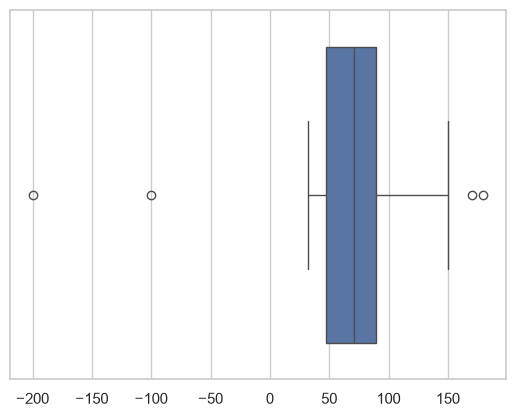

In [100]:
# WHAT: extreme values unna marks list ki boxplot draw chestunnam.
# WHY: boxplot outlier points ni whiskers outside separate dots laga chupistundi.
sns.boxplot(x=outlier_marks_with_extremes)


In [101]:
# WHAT: extreme values unna list ki 5 number summary malli calculate chestunnam.
# WHY: outliers add chesaka Q1, Q3, IQR, fences ela change avutayo understand cheyyali.
extreme_minimum, extreme_Q1, extreme_median, extreme_Q3, extreme_maximum = np.quantile(outlier_marks_with_extremes, [0, 0.25, 0.50, 0.75, 1.0])

# WHAT: extreme list IQR calculate chestunnam.
# WHY: new fences calculate cheyyadaniki updated spread kavali.
extreme_IQR = extreme_Q3 - extreme_Q1

# WHAT: extreme list lower fence calculate chestunnam.
# WHY: low-side outlier threshold identify cheyyali.
extreme_lower_fence = extreme_Q1 - 1.5 * extreme_IQR

# WHAT: extreme list higher fence calculate chestunnam.
# WHY: high-side outlier threshold identify cheyyali.
extreme_higher_fence = extreme_Q3 + 1.5 * extreme_IQR

# WHAT: fences outside unna values ni outliers ga collect chestunnam.
# WHY: boxplot visual result ni actual numeric list tho verify cheyyali.
detected_outliers = [mark for mark in outlier_marks_with_extremes if mark < extreme_lower_fence or mark > extreme_higher_fence]

# WHAT: summary dictionary display chestunnam.
# WHY: thresholds and detected outliers one place lo easy ga compare cheyyadaniki.
{
    "minimum": extreme_minimum,
    "Q1": extreme_Q1,
    "median": extreme_median,
    "Q3": extreme_Q3,
    "maximum": extreme_maximum,
    "IQR": extreme_IQR,
    "lower_fence": extreme_lower_fence,
    "higher_fence": extreme_higher_fence,
    "detected_outliers": detected_outliers,
}


{'minimum': np.float64(-200.0),
 'Q1': np.float64(47.25),
 'median': np.float64(70.5),
 'Q3': np.float64(89.75),
 'maximum': np.float64(180.0),
 'IQR': np.float64(42.5),
 'lower_fence': np.float64(-16.5),
 'higher_fence': np.float64(153.5),
 'detected_outliers': [-100, -200, 170, 180]}

## Handling Outliers - Key Points

- 5-number summary data spread ni quickly understand cheyyadaniki use chestham.
- IQR = Q3 - Q1. Idi middle 50 percent data spread.
- Lower fence = Q1 - 1.5 * IQR.
- Higher fence = Q3 + 1.5 * IQR.
- Fence outside values possible outliers.
- Boxplot outliers ni visual ga identify cheyyadaniki best simple chart.
- Outlier ani detect chesina ventane delete cheyyakudadhu; domain batti valid aa error aa decide cheyyali.
- Handling options: remove, cap/winsorize, transform, separate anomaly feature create cheyyadam, or keep as valid extreme values.


## Source Notebook Sections: Data Encoding

Ee section `5.0-Nominal+or+OHE.ipynb`, `7.0-Label+and+Ordinal.ipynb`, and `8.0-Target+Guided+Ordinal+Encoding.ipynb` content ni explain chestundi.

Important note: `5.0-Nominal+or+OHE.ipynb` and `7.0-Label+and+Ordinal.ipynb` source content identical ga undi. So duplicate ga same cells two times add cheyyakunda, oka clean consolidated section lo Nominal/OHE, Label Encoding, and Ordinal Encoding cover chestunnam. Third file lo unna Target Guided Ordinal Encoding ni separate ga add chestunnam.

### Data Encoding ante enti?

Data encoding ante categorical/text values ni numeric values ga convert cheyyadam. ML models mostly numbers tho work chestayi, kabatti `red`, `blue`, `small`, `large`, `city` lanti text columns ni numbers ga marchali.

```text
[Categorical/Text Data]
        |
        v
[Choose Encoding Type]
        |
        +--> [Nominal/OHE: no order]
        |
        +--> [Label Encoding: simple labels]
        |
        +--> [Ordinal Encoding: meaningful order]
        |
        +--> [Target Guided Encoding: target relationship]
        |
        v
[Numeric Features for ML Model]
```


### Nominal/OHE Encoding

Original notebook meaning: One Hot Encoding categorical data ni numerical data ga represent cheyyadaniki use chestham. Prathi category ki separate binary column create avutundi.

**What are we doing?** `color` column lo `red`, `blue`, `green` categories unnayi. OHE taruvatha `color_red`, `color_blue`, `color_green` lanti columns create avutayi.

**Why are we doing it?** Colors ki natural order ledu. Red > Blue ani meaning ledu. Kabatti single numbers 1,2,3 assign chesthe model wrong order assume cheyyachu. OHE avoids that fake order.

Example:

1. Red: `[1, 0, 0]`
2. Green: `[0, 1, 0]`
3. Blue: `[0, 0, 1]`


In [102]:
# WHAT: pandas ni import chestunnam because sample dataframe create cheyyali.
# WHY: categorical column ni table format lo represent cheyyadam pandas tho easy.
import pandas as pd

# WHAT: OneHotEncoder ni sklearn preprocessing nunchi import chestunnam.
# WHY: nominal categories ni binary numeric columns ga convert cheyyadaniki.
from sklearn.preprocessing import OneHotEncoder


In [103]:
# WHAT: color ane categorical column tho sample dataframe create chestunnam.
# WHY: red, blue, green ki natural ranking ledu, so OHE demo ki perfect example.
color_df = pd.DataFrame({
    # WHAT: color values list store chestunnam.
    # WHY: repeated categories unte encoder each unique category identify cheyyagaladu.
    "color": ["red", "blue", "green", "green", "red", "blue"]
})


In [104]:
# WHAT: sample dataframe first rows display chestunnam.
# WHY: encoding before original text categories ela unnayo observe cheyyali.
color_df.head()


,color
0,red
1,blue
2,green
3,green
4,red


In [105]:
# WHAT: OneHotEncoder object create chestunnam.
# WHY: ee object categories learn chesi binary matrix create chestundi.
# sparse_output=False ante direct dense array output ravadaniki, notebook lo easy ga display cheyyadaniki.
one_hot_encoder = OneHotEncoder(sparse_output=False)


In [106]:
# WHAT: color column meeda encoder ni fit and transform chestunnam.
# WHY: fit step categories learn chestundi; transform step text values ni binary numeric rows ga convert chestundi.
encoded_colors = one_hot_encoder.fit_transform(color_df[["color"]])


In [107]:
# WHAT: encoded array ni dataframe ga convert chestunnam.
# WHY: binary columns ki readable names ravali, e.g. color_blue, color_green, color_red.
encoded_color_df = pd.DataFrame(encoded_colors, columns=one_hot_encoder.get_feature_names_out(["color"]))


In [108]:
# WHAT: encoded dataframe display chestunnam.
# WHY: prathi color row lo correct binary column 1 ayyindo verify cheyyali.
encoded_color_df


,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


In [109]:
# WHAT: new unseen input row lo color blue ni transform chestunnam.
# WHY: model production lo new data vachinappudu same encoder use chesi same column format lo convert cheyyali.
one_hot_encoder.transform(pd.DataFrame({"color": ["blue"]}))


array([[1., 0., 0.]])

In [110]:
# WHAT: original color column and encoded columns ni side-by-side combine chestunnam.
# WHY: original category ela binary features ga convert ayyindo clearly compare cheyyadaniki.
pd.concat([color_df, encoded_color_df], axis=1)


,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,green,0.0,1.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0
5,blue,1.0,0.0,0.0


In [111]:
# WHAT: seaborn library ni import chestunnam.
# WHY: original notebook tips dataset load chestundi; categorical dataset example ga useful.
import seaborn as sns

# WHAT: tips dataset ni load chestunnam.
# WHY: real-like categorical columns such as sex, smoker, day, time practice cheyyadaniki.
tips_df = sns.load_dataset("tips")

# WHAT: tips dataset first rows display chestunnam.
# WHY: real dataset lo categorical columns ela untayo observe cheyyadaniki.
tips_df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Label Encoding

Original notebook meaning: Label Encoding categorical values ki unique numerical label assign chestundi.

**What are we doing?** `red`, `blue`, `green` colors ni 0, 1, 2 lanti integer labels ga convert chestham.

**Why are we doing it?** Konni algorithms target labels ki numbers expect chestayi. Example target column `spam`, `not_spam` ni 0/1 ga convert cheyyali.

**Important caution:** Feature column lo nominal categories ki Label Encoding use chesthe model fake order assume cheyyachu. Example `green=1`, `red=2` ante red green kanna greater ani wrong relation create avvachu. Nominal input features ki OHE safer.


In [112]:
# WHAT: OHE section lo create chesina original color dataframe display chestunnam.
# WHY: same color data meeda label encoding effect compare cheyyali.
color_df.head()


,color
0,red
1,blue
2,green
3,green
4,red


In [113]:
# WHAT: LabelEncoder ni sklearn preprocessing nunchi import chestunnam.
# WHY: categories ni integer labels ga convert cheyyadaniki.
from sklearn.preprocessing import LabelEncoder

# WHAT: LabelEncoder object create chestunnam.
# WHY: object categories learn chesi integer mapping maintain chestundi.
label_encoder = LabelEncoder()


In [114]:
# WHAT: color column ni fit_transform chestunnam.
# WHY: encoder unique colors learn chesi each row ki integer code assign chestundi.
# Note: LabelEncoder expects 1D input, so color_df["color"] use chestunnam.
color_df["color_label"] = label_encoder.fit_transform(color_df["color"])

# WHAT: label encoded dataframe display chestunnam.
# WHY: color to number mapping practical ga chudataniki.
color_df


,color,color_label
0,red,2
1,blue,0
2,green,1
3,green,1
4,red,2
5,blue,0


In [115]:
# WHAT: red category ni trained label encoder tho transform chestunnam.
# WHY: production/new data lo same mapping apply avutundo verify cheyyali.
label_encoder.transform(["red"])


array([2])

In [116]:
# WHAT: blue category ni trained label encoder tho transform chestunnam.
# WHY: blue ki assigned numeric label enti ani chudali.
label_encoder.transform(["blue"])


array([0])

In [117]:
# WHAT: green category ni trained label encoder tho transform chestunnam.
# WHY: green ki assigned numeric label enti ani chudali.
label_encoder.transform(["green"])


array([1])

### Ordinal Encoding

Original notebook meaning: Ordinal Encoding ordered categorical data ki use chestham. Category order meaningful ga unte numbers assign chestham.

**What are we doing?** `small < medium < large` order define chestham and encoder ki categories order explicit ga cheptam.

**Why are we doing it?** Size lo natural ranking undi. `large` > `medium` > `small` ane relation meaningful. Kabatti ordered numeric encoding useful.

Example:

1. Small: 0
2. Medium: 1
3. Large: 2


In [118]:
# WHAT: OrdinalEncoder ni sklearn preprocessing nunchi import chestunnam.
# WHY: ordered categories ni order-preserving numbers ga convert cheyyadaniki.
from sklearn.preprocessing import OrdinalEncoder


In [119]:
# WHAT: size column tho ordinal sample dataframe create chestunnam.
# WHY: small, medium, large ki natural order undi, so ordinal encoding demo ki suitable.
size_df = pd.DataFrame({
    # WHAT: size category values list store chestunnam.
    # WHY: repeated ordered categories ni encoder convert cheyyali.
    "size": ["small", "medium", "large", "medium", "small", "large"]
})


In [120]:
# WHAT: size dataframe display chestunnam.
# WHY: encoding before original ordered categories chudali.
size_df


,size
0,small
1,medium
2,large
3,medium
4,small
5,large


In [121]:
# WHAT: OrdinalEncoder object create chestunnam and category order manually specify chestunnam.
# WHY: encoder alphabetical order guess cheyyakunda mana real order small -> medium -> large follow avvali.
ordinal_encoder = OrdinalEncoder(categories=[["small", "medium", "large"]])


In [122]:
# WHAT: size column ni ordinal numbers ga convert chestunnam.
# WHY: ML model ordered size relation ni numeric feature laga use cheyyagaladu.
size_df["size_encoded"] = ordinal_encoder.fit_transform(size_df[["size"]])

# WHAT: original and encoded size columns display chestunnam.
# WHY: small=0, medium=1, large=2 mapping verify cheyyali.
size_df


,size,size_encoded
0,small,0.0
1,medium,1.0
2,large,2.0
3,medium,1.0
4,small,0.0
5,large,2.0


In [123]:
# WHAT: new value small ni ordinal encoder tho transform chestunnam.
# WHY: production/new input lo same ordered mapping apply avvali.
ordinal_encoder.transform(pd.DataFrame({"size": ["small"]}))


array([[0.]])

## Target Guided Ordinal Encoding

Original notebook meaning: Target Guided Ordinal Encoding categorical variables ni target variable relationship base chesi encode chestundi.

**What are we doing?** City category ki average target value calculate chestham. Example city-wise average `price`. Taruvatha each city ni aa average price tho replace chestham.

**Why are we doing it?** City lanti category ki many unique values unte OHE chala columns create chestundi. Target-guided encoding category impact ni one numeric column lo capture chestundi.

**Important caution:** Idi target variable use chestundi kabatti leakage risk undi. Real ML lo train data meeda mapping learn chesi test data ki apply cheyyali. Full data meeda mapping create chesthe target leakage avvachu.


In [124]:
# WHAT: pandas already imported undi, but target-guided section independent ga understandable ga undadaniki mention chestunnam.
# WHY: dataframe create and groupby calculations kosam pandas kavali.
import pandas as pd

# WHAT: city categorical column and price target column tho sample dataframe create chestunnam.
# WHY: city-wise average price calculate chesi city ni target relationship base chesi encode cheyyali.
city_price_df = pd.DataFrame({
    # WHAT: repeated city categories store chestunnam.
    # WHY: groupby city mean calculate cheyyadaniki repeated categories kavali.
    "city": ["New York", "London", "Paris", "Tokyo", "New York", "Paris"],
    # WHAT: price values target/numeric output laga store chestunnam.
    # WHY: prathi city average price target-guided encoding value avuthundi.
    "price": [200, 150, 300, 250, 180, 320],
})


In [125]:
# WHAT: city-price sample dataframe display chestunnam.
# WHY: encoding before original city and price values observe cheyyali.
city_price_df


,city,price
0,New York,200
1,London,150
2,Paris,300
3,Tokyo,250
4,New York,180
5,Paris,320


In [126]:
# WHAT: city-wise average price calculate chesi dictionary ga convert chestunnam.
# WHY: each city category ni target mean value tho replace cheyyadaniki mapping kavali.
mean_price_by_city = city_price_df.groupby("city")["price"].mean().to_dict()


In [127]:
# WHAT: city to mean-price mapping display chestunnam.
# WHY: New York, Paris lanti cities ki final encoded values enti ani chudali.
mean_price_by_city


{'London': 150.0, 'New York': 190.0, 'Paris': 310.0, 'Tokyo': 250.0}

In [128]:
# WHAT: city column values ni mean_price_by_city dictionary values tho map chestunnam.
# WHY: text city feature numeric target-guided feature ga convert avvali.
city_price_df["city_encoded"] = city_price_df["city"].map(mean_price_by_city)


In [129]:
# WHAT: original price and encoded city columns display chestunnam.
# WHY: city category target mean relationship numeric feature ga ela vachindo compare cheyyali.
city_price_df[["city", "price", "city_encoded"]]


,city,price,city_encoded
0,New York,200,190.0
1,London,150,150.0
2,Paris,300,310.0
3,Tokyo,250,250.0
4,New York,180,190.0
5,Paris,320,310.0


In [130]:
# WHAT: seaborn library ni import chestunnam.
# WHY: original notebook target-guided section end lo tips dataset load chestundi.
import seaborn as sns

# WHAT: tips dataset load chestunnam.
# WHY: real dataset lo categorical columns and numeric target examples practice cheyyadaniki.
target_guided_tips_df = sns.load_dataset("tips")

# WHAT: tips dataframe first rows display chestunnam.
# WHY: total_bill, tip, sex, smoker, day, time lanti columns target-guided encoding practice ki useful ani observe cheyyali.
target_guided_tips_df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Data Encoding Key Points

- ML models numeric input expect chestayi, so categorical data encode cheyyali.
- Nominal/OHE no-order categories ki best: color, city, department.
- Label Encoding target labels ki useful, but nominal feature columns ki fake order risk undi.
- Ordinal Encoding meaningful order unna categories ki best: small/medium/large, low/medium/high.
- Target Guided Encoding category-target relationship use chestundi, but leakage avoid cheyyali.
- Real project lo encoder train data meeda fit chesi, validation/test/production data meeda transform cheyyali.


## Manual Feature Engineering Example

Ikkada manual ga konni useful features create chestham:

- `tenure_years`: employee company lo entha kalam work chestunnadu.
- `salary_per_experience_year`: salary experience tho compare chesthe ela undi.
- `age_group`: age ni groups ga bin cheyyadam.
- `is_tech_department`: department Engineering aithe 1, lekapothe 0.
- `joining_month`: date nunchi month extract cheyyadam.


In [66]:
# original dataframe copy create chestunnam, original data safe ga undadaniki.
engineered_dataframe = employee_dataframe.copy()

# reference date ni tenure calculate cheyyadaniki fixed date ga set chestunnam.
reference_date = pd.Timestamp("2026-01-01")

# joining date nunchi tenure years calculate chestunnam.
engineered_dataframe["tenure_years"] = ((reference_date - engineered_dataframe["joining_date"]).dt.days / 365).round(2)

# experience zero unna divide-by-zero avoid cheyyadaniki denominator lo 1 add chestunnam.
engineered_dataframe["salary_per_experience_year"] = (engineered_dataframe["monthly_salary"] / (engineered_dataframe["experience_years"] + 1)).round(2)

# age values ni young, mid, senior bins ga convert chestunnam.
engineered_dataframe["age_group"] = pd.cut(engineered_dataframe["age"], bins=[20, 30, 45, 60], labels=["young", "mid", "senior"])

# department engineering aithe 1 lekapothe 0 ani binary feature create chestunnam.
engineered_dataframe["is_tech_department"] = (engineered_dataframe["department"] == "Engineering").astype(int)

# joining date nunchi month number extract chestunnam.
engineered_dataframe["joining_month"] = engineered_dataframe["joining_date"].dt.month

# engineered columns tho first rows display chestunnam.
engineered_dataframe[["age", "age_group", "monthly_salary", "experience_years", "salary_per_experience_year", "tenure_years", "department", "is_tech_department", "joining_month"]].head(10)


,age,age_group,monthly_salary,experience_years,salary_per_experience_year,tenure_years,department,is_tech_department,joining_month
0,50.0,senior,91098.0,5.0,15183.00,8.01,Finance,0,1
1,36.0,mid,88590.0,15.0,5536.88,7.92,Finance,0,1
2,29.0,young,71271.0,2.0,23757.00,7.84,Finance,0,3
3,42.0,mid,63777.0,19.0,3188.85,7.76,HR,0,4
4,NaN,NaN,47853.0,3.0,11963.25,7.68,HR,0,5
5,44.0,mid,94794.0,18.0,4989.16,7.59,Engineering,1,5
6,32.0,mid,71801.0,2.0,23933.67,7.51,Finance,0,6
7,32.0,mid,67613.0,18.0,3558.58,7.43,Engineering,1,7
8,45.0,mid,96235.0,19.0,4811.75,7.35,Finance,0,8
9,57.0,senior,NaN,6.0,NaN,7.27,Finance,0,9


## Visualization: Feature Relationship Chuddam

Feature engineering lo visualization useful. Target tho feature relationship ela undi ani chusthe, new feature useful aa kada ani idea vastundi.


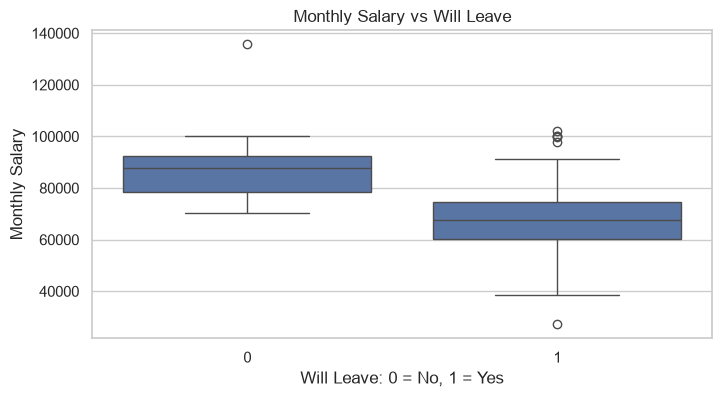

In [67]:
# chart size ni readable ga set chestunnam.
plt.figure(figsize=(8, 4))

# will_leave target base chesi salary distribution plot chestunnam.
sns.boxplot(data=engineered_dataframe, x="will_leave", y="monthly_salary")

# chart title ni set chestunnam.
plt.title("Monthly Salary vs Will Leave")

# x-axis label ni readable ga set chestunnam.
plt.xlabel("Will Leave: 0 = No, 1 = Yes")

# y-axis label ni readable ga set chestunnam.
plt.ylabel("Monthly Salary")

# chart ni display chestunnam.
plt.show()


## Production-Style Pipeline

Manual feature engineering learning kosam baaguntundi, kaani real ML workflow lo pipeline use cheyyadam better. Pipeline valla train data preprocessing rules test data ki same ga apply avutayi. Data leakage avoid cheyyadaniki idi important.

Pipeline lo:

1. Numeric columns ki median imputation + scaling apply chestham.
2. Categorical columns ki most frequent imputation + one-hot encoding apply chestham.
3. Final transformed data ni model ki pass chestham.


In [68]:
# pipeline kosam selected features list create chestunnam.
feature_columns = ["age", "monthly_salary", "experience_years", "projects_completed", "department", "city"]

# target column name ni separate ga store chestunnam.
target_column = "will_leave"

# input features ni X variable lo store chestunnam.
X = employee_dataframe[feature_columns]

# target labels ni y variable lo store chestunnam.
y = employee_dataframe[target_column]

# numeric columns list ni define chestunnam.
numeric_features = ["age", "monthly_salary", "experience_years", "projects_completed"]

# categorical columns list ni define chestunnam.
categorical_features = ["department", "city"]

# train and test split create chestunnam, model unseen data meeda evaluate avvadaniki.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# numeric preprocessing pipeline create chestunnam.
numeric_pipeline = Pipeline(steps=[
    # missing numeric values ni median tho fill chestunnam.
    ("imputer", SimpleImputer(strategy="median")),
    # numeric values ni standard scale lo ki convert chestunnam.
    ("scaler", StandardScaler()),
])

# categorical preprocessing pipeline create chestunnam.
categorical_pipeline = Pipeline(steps=[
    # missing categorical values ni most frequent category tho fill chestunnam.
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # categorical values ni one-hot numeric columns ga convert chestunnam.
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

# numeric and categorical preprocessing ni single transformer lo combine chestunnam.
preprocessor = ColumnTransformer(transformers=[
    # numeric columns ki numeric pipeline apply chestunnam.
    ("numeric", numeric_pipeline, numeric_features),
    # categorical columns ki categorical pipeline apply chestunnam.
    ("categorical", categorical_pipeline, categorical_features),
])

# preprocessing plus model ni one complete ML pipeline ga create chestunnam.
model_pipeline = Pipeline(steps=[
    # raw input ni model-ready numeric matrix ga convert chestunnam.
    ("preprocessor", preprocessor),
    # logistic regression classification model ni train cheyyadaniki attach chestunnam.
    ("model", LogisticRegression(max_iter=1000)),
])

# train data meeda complete pipeline ni fit chestunnam.
model_pipeline.fit(X_train, y_train)

# test data meeda predictions generate chestunnam.
test_predictions = model_pipeline.predict(X_test)

# accuracy score calculate chestunnam.
test_accuracy = accuracy_score(y_test, test_predictions)

# accuracy ni readable format lo print chestunnam.
print(f"Test Accuracy: {test_accuracy:.2f}")

# detailed classification report print chestunnam.
print("\nClassification Report:")
print(classification_report(y_test, test_predictions))


Test Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.62      0.67         8
           1       0.77      0.83      0.80        12

    accuracy                           0.75        20
   macro avg       0.74      0.73      0.73        20
weighted avg       0.75      0.75      0.75        20



## Transformed Feature Names Chuddam

Pipeline after preprocessing, original columns multiple model-ready columns ga marutayi. Especially one-hot encoding valla categorical column values separate binary columns ga convert avutayi.


In [69]:
# trained preprocessor ni pipeline nunchi access chestunnam.
trained_preprocessor = model_pipeline.named_steps["preprocessor"]

# transformed feature names ni sklearn nunchi get chestunnam.
transformed_feature_names = trained_preprocessor.get_feature_names_out()

# first 20 transformed features ni series format lo display chestunnam.
pd.Series(transformed_feature_names).head(20)


0                            numeric__age
1                 numeric__monthly_salary
2               numeric__experience_years
3             numeric__projects_completed
4     categorical__department_Engineering
5         categorical__department_Finance
6              categorical__department_HR
7           categorical__department_Sales
8             categorical__city_Bengaluru
9               categorical__city_Chennai
10            categorical__city_Hyderabad
11                 categorical__city_Pune
dtype: str

## Important Concepts and Gotchas

### 1. Data Leakage Avoid Cheyyali

Train-test split mundu full data meeda imputation/scaling fit chesthe leakage jarugutundi. Test data information train process lo leak avutundi. Correct way: train data meeda fit cheyyali, test data meeda transform matrame cheyyali. Pipeline idi safe ga handle chestundi.

### 2. Scaling Every Model Ki Same Importance Kaadu

Linear regression, logistic regression, KNN, SVM, neural networks ki scaling chala important. Tree models like Decision Tree, Random Forest, XGBoost ki scaling usually less important.

### 3. One-Hot Encoding High Cardinality Problem

City column lo 4 categories unte fine. Kaani user_id column lo 1 lakh unique values unte one-hot encoding huge matrix create chestundi. Alanti cases lo target encoding, frequency encoding, embeddings lanti approaches consider cheyyali.

### 4. Domain Knowledge Chala Important

Feature engineering pure coding kaadu. Business/domain meaning teliste best features create cheyachu. Example ecommerce lo `cart_value_per_item`, `days_since_last_purchase`, `discount_percentage` lanti features useful.

### 5. Feature Selection Kuda Important

Too many useless features model ni noisy ga chestayi. Correlation, model importance, permutation importance, regularization lanti methods tho useful features identify cheyyali.


## Real Project Working Flow

```text
1. Problem define cheyyi
   Example: customer churn predict cheyyali.

2. Raw data collect cheyyi
   Customer profile, transactions, support tickets, app usage data collect chestham.

3. Data audit cheyyi
   Missing values, duplicate rows, outliers, wrong data types identify chestham.

4. Basic preprocessing cheyyi
   Missing values impute cheyyi, categories encode cheyyi, numeric columns scale cheyyi.

5. Domain features create cheyyi
   days_since_last_login, average_order_value, complaints_count lanti features create chestham.

6. Train-test split safe ga maintain cheyyi
   Leakage avoid cheyyadaniki preprocessing train data meeda fit cheyyi.

7. Model train cheyyi
   Baseline model first, then better models try cheyyi.

8. Evaluate cheyyi
   Accuracy, precision, recall, F1, ROC-AUC problem batti check cheyyi.

9. Iterate cheyyi
   Bad predictions analyze chesi new features create cheyyi.

10. Production pipeline save cheyyi
    Same preprocessing production data ki apply avvali.
```


## Summary

Feature engineering ante raw data ni model ki useful signals ga convert cheyyadam. Idi ML lo one of the most important steps. Missing values handle cheyyadam, categorical encoding, scaling, transformations, date feature extraction, binning, domain-based new features, and feature selection anni feature engineering part.

Gurthu pettukovali:

- Good features model performance ni strongly improve chestayi.
- Pipeline use chesthe preprocessing consistent ga untundi.
- Train data meeda fit, test data meeda transform ane rule follow cheyyali.
- Domain knowledge tho created features often best results istayi.
- Feature engineering one-time step kaadu; model errors chusi iterate cheyyali.
